In [30]:
import threading
import time
import random
import mysql.connector
from mysql.connector import pooling
from pymongo import MongoClient, UpdateOne
from datetime import datetime
from dotenv import load_dotenv
import os
import sys
import matplotlib.pyplot as plt
from pathlib import Path
import math


# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Load environment and establish connections
ENV_PATH = PROJECT_ROOT / ".env"
load_dotenv(dotenv_path=ENV_PATH, override=True)

# Get credentials
db_name = os.getenv("DB_NAME", "bookrec")
host = os.getenv("HOST", "localhost")
msql_user = os.getenv("MSQL_USER")
msql_password = os.getenv("MSQL_PASSWORD")
msql_port = os.getenv("MSQL_PORT", "3306")
mdb_user = os.getenv("MDB_USER")
mdb_password = os.getenv("MDB_PASSWORD")


mdb_cluster = os.getenv("MDB_CLUSTER")
mdb_appname = os.getenv("MDB_APPNAME", "Cluster0")
mdb_use_atlas = os.getenv("MDB_USE_ATLAS", "false").lower() == "true"

mongodb_uri = f"mongodb+srv://{mdb_user}:{mdb_password}@{mdb_cluster}/?retryWrites=true&w=majority&appName={mdb_appname}"

# Validate credentials
if not all([msql_user, msql_password, mdb_user, mdb_password]):
    raise ValueError("Database credentials missing in .env file!")

print("✓ Credentials loaded")

✓ Credentials loaded


In [31]:
# --- CONFIGURATION ---
MYSQL_CONFIG = {
    'user': msql_user, 
    'password': msql_password,
    'host': host, 
    'database': db_name
}

MONGO_URI = mongodb_uri
DB_NAME = db_name

NUM_USERS = 50      # Number of concurrent simulated users
DURATION_SEC = 5     # Duration of the test in seconds


# --- GLOBALS & OPTIMIZATIONS ---

# 1. MongoDB Global Client (Thread-safe)
# Initialize once to avoid SSL handshake latency on every request
mongo_client = MongoClient(MONGO_URI)
mongo_db = mongo_client[DB_NAME]

# 2. MySQL Connection Pool
# Create a pool of open connections ready to be used

POOLS = []
POOL_SIZE_PER_POOL = 30

num_pools_needed = math.ceil(NUM_USERS / POOL_SIZE_PER_POOL)

for i in range(num_pools_needed):
    try:
        pool = mysql.connector.pooling.MySQLConnectionPool(
            pool_name=f"mypool_{i}",
            pool_size=POOL_SIZE_PER_POOL,
            pool_reset_session=True,
            **MYSQL_CONFIG
        )
        POOLS.append(pool)
    except Exception as e:
        print(f"[ERROR] Imposible to create pool {i}: {e}")

# Global variable to store the target ISBN
ALL_TEST_ISBNS = []
TARGET_ISBN = None
CONFLICT_ISBN_A = None
CONFLICT_ISBN_B = None

# --- METRICS STORE ---
stats = {
    "read_ops": 0, "read_errors": 0, "read_time": [],
    "write_ops": 0, "write_errors": 0, "write_time": [],
    "deadlocks": 0
}
stats_lock = threading.Lock()

def get_mysql_connection_from_any_pool():
    return random.choice(POOLS).get_connection()

# --- SETUP ---

def setup_test_data():
    """Prepares test data and ensures the target book exists."""
    global TARGET_ISBN, ALL_TEST_ISBNS, CONFLICT_ISBN_A, CONFLICT_ISBN_B
    print("[INFO] Preparing data...")
    
    try:
        cnx = get_mysql_connection_from_any_pool()
        cursor = cnx.cursor()

        # 1. Create dummy users
        for uid in range(1000, 1000 + NUM_USERS):
            cursor.execute("""
                INSERT IGNORE INTO users 
                (user_id, age, age_group, gender, country, has_preferences, has_ratings) 
                VALUES (%s, %s, %s, %s, %s, %s, %s)
            """, (uid, 25, 'Adult', 'Unknown', 'US', 1, 1))

        # 2. CHARGEMENT DE MASSE DES ISBNS (Pour éviter l'effet Cache)
        # On récupère jusqu'à 1000 livres différents
        cursor.execute("SELECT isbn FROM books LIMIT 1000")
        rows = cursor.fetchall()
        
        if rows:
            # On transforme la liste de tuples en liste simple : ['isbn1', 'isbn2', ...]
            ALL_TEST_ISBNS = [row[0] for row in rows]
            
            # On définit quand même les cibles spécifiques pour les autres tests
            TARGET_ISBN = ALL_TEST_ISBNS[0]
            if len(ALL_TEST_ISBNS) >= 2:
                CONFLICT_ISBN_A = ALL_TEST_ISBNS[0]
                CONFLICT_ISBN_B = ALL_TEST_ISBNS[1]
            
            print(f"[INFO] Loaded {len(ALL_TEST_ISBNS)} ISBNs for random testing.")
        else:
            print("[ERROR] No books found in MySQL.")
            return

        cnx.commit()
        cursor.close()
        cnx.close() 

        # 3. INITIALISATION DE MASSE MONGODB (Bulk Write)
        # On prépare 1000 opérations d'un coup, c'est beaucoup plus rapide
        print(f"[INFO] Bulk initializing {len(ALL_TEST_ISBNS)} docs in MongoDB...")
        
        mongo_ops = []
        for isbn in ALL_TEST_ISBNS:
            op = UpdateOne(
                {"_id": isbn},
                {
                    "$setOnInsert": {
                        "extra_metadata": {"genre": "Test Genre"},
                        "rating_metrics": {"r_count": 0, "r_total": 0, "rating_score": 0}
                    }
                },
                upsert=True # Crée le document seulement s'il n'existe pas
            )
            mongo_ops.append(op)
        
        if mongo_ops:
            mongo_db.books_metadata.bulk_write(mongo_ops)
            
        print("[OK] MongoDB and MySQL ready.")

    except Exception as e:
        print(f"[CRITICAL ERROR] Setup failed: {e}")

# --- TASKS ---

def task_read_recommendation(user_id):
    """Read: Mongo Profile + MySQL Stats for specific books (Optimized)"""
    start = time.time()
    cnx = None
    try:
        # 1. Mongo (Fetch preferences)
        user_profile = mongo_db.users_profiles.find_one(
            {"_id": user_id},
            {"preferences": 1}
        )
        
        # 2. MySQL (Optimized with IN clause)
        cnx = get_mysql_connection_from_any_pool()
        cursor = cnx.cursor()
        
        # Simulation: User views a page with 5 specific books
        target_isbns = [random.choice(ALL_TEST_ISBNS), random.choice(ALL_TEST_ISBNS), random.choice(ALL_TEST_ISBNS), random.choice(ALL_TEST_ISBNS), random.choice(ALL_TEST_ISBNS)]
        placeholders = ', '.join(['%s'] * len(target_isbns))
        
        query = f"""
            SELECT b.title, AVG(r.rating) as note, COUNT(r.rating) as volume
            FROM ratings r
            JOIN books b ON r.isbn = b.isbn
            WHERE r.isbn IN ({placeholders})  -- Optimization: Filter using Index
            GROUP BY b.isbn
            ORDER BY note DESC
        """
        
        cursor.execute(query, target_isbns)
        books = cursor.fetchall()
        
        cursor.close()
        
        duration = time.time() - start
        with stats_lock:
            stats["read_ops"] += 1
            stats["read_time"].append(duration)
            
    except Exception as e:
        with stats_lock:
            stats["read_errors"] += 1
        print(f"Read Error: {e}")
    finally:
        if cnx:
            try: cnx.close()
            except: pass

def task_rate_book(user_id):
    """Write: MySQL Insert + Mongo Increment"""
    isbn = random.choice(ALL_TEST_ISBNS)
    rating = random.randint(1, 10)
    
    start = time.time()
    cnx = None
    try:
        # 1. MySQL Write (Via Pool)
        cnx = get_mysql_connection_from_any_pool()
        cursor = cnx.cursor()
        
        query = """
        INSERT INTO ratings (user_id, isbn, rating, r_seq_user, r_seq_book, r_cat) 
        VALUES (%s, %s, %s, 0, 0, 'explicit')
        ON DUPLICATE KEY UPDATE rating = %s
        """
        cursor.execute(query, (user_id, isbn, rating, rating))
        cnx.commit()
        cursor.close()

        # 2. Mongo Update (Global client)
        mongo_db.books_metadata.update_one(
            {"_id": isbn},
            {
                "$inc": {
                    "rating_metrics.r_count": 1,
                    "rating_metrics.r_total": rating
                },
                "$set": {"updated_at": datetime.now()}
            }
        )
        
        duration = time.time() - start
        with stats_lock:
            stats["write_ops"] += 1
            stats["write_time"].append(duration)

    except mysql.connector.errors.DatabaseError as err:
        if err.errno == 1213: # Deadlock
            with stats_lock:
                stats["deadlocks"] += 1
            print(f"Deadlock detected for user {user_id}")
        else:
            with stats_lock:
                stats["write_errors"] += 1
            print(f"MySQL Error: {err}")
    except Exception as e:
        with stats_lock:
            stats["write_errors"] += 1
        print(f"Other Write Error: {e}")
    finally:
        if cnx:
            try: cnx.close()
            except: pass

def task_simulate_deadlock(user_id):
    """
    DEADLOCK TRAP WITH RETRY:
    Attempts to update two books in reverse order.
    If a deadlock occurs, waits and retries up to 3 times.
    """
    max_retries = 3
    attempt = 0
    
    while attempt < max_retries:
        cnx = None
        try:
            # Randomize direction (A->B or B->A)
            direction = random.choice(["A_TO_B", "B_TO_A"])
            first_isbn = CONFLICT_ISBN_A if direction == "A_TO_B" else CONFLICT_ISBN_B
            second_isbn = CONFLICT_ISBN_B if direction == "A_TO_B" else CONFLICT_ISBN_A

            cnx = get_mysql_connection_from_any_pool()
            cnx.autocommit = False 
            cursor = cnx.cursor()

            # 1. Lock first book
            cursor.execute("SELECT title FROM books WHERE isbn = %s FOR UPDATE", (first_isbn,))
            cursor.fetchone()
            
            # Pause to allow the other thread to lock the other book
            time.sleep(random.uniform(0.05, 0.2)) 

            # 2. Attempt to lock second book (This causes the deadlock)
            cursor.execute("SELECT title FROM books WHERE isbn = %s FOR UPDATE", (second_isbn,))
            cursor.fetchone()

            cnx.commit()
            return # Success

        except mysql.connector.errors.DatabaseError as err:
            if err.errno == 1213: # DEADLOCK
                attempt += 1
                with stats_lock:
                    stats["deadlocks"] += 1 
                
                print(f"[RETRY {attempt}/{max_retries}] User {user_id} stuck ({direction})...")
                
                if cnx:
                    try: cnx.rollback()
                    except: pass
                
                # Random backoff wait
                time.sleep(random.uniform(0.2, 1.0))
            else:
                print(f"MySQL Error (Non-deadlock): {err}")
                break
                
        except Exception as e:
            print(f"Error: {e}")
            break
            
        finally:
            if cnx:
                try:
                    cnx.autocommit = True
                    cnx.close()
                except: pass

    print(f"[FAIL] User {user_id} gave up after {max_retries} attempts.")

def task_consistency_check(user_id):
    """
    CONSISTENCY CHECK:
    Writes to MySQL and immediately checks Mongo.
    Measures 'Eventual Consistency' lag.
    """
    isbn = TARGET_ISBN
    new_rating = random.randint(1, 10)
    
    cnx = None
    try:
        # 1. MySQL Write
        cnx = get_mysql_connection_from_any_pool()
        cursor = cnx.cursor()
        cursor.execute("""
            INSERT INTO ratings (user_id, isbn, rating, r_seq_user, r_seq_book, r_cat) 
            VALUES (%s, %s, %s, 0, 0, 'explicit')
            ON DUPLICATE KEY UPDATE rating = %s
        """, (user_id, isbn, new_rating, new_rating))
        cnx.commit()
        cursor.close()
        cnx.close()

        # 2. Mongo Update (simulate backend sync)
        mongo_db.books_metadata.update_one(
            {"_id": isbn},
            {"$set": {"last_rating_check": new_rating, "updated_at": datetime.now()}}
        )

        # 3. Immediate Read (Check)
        doc = mongo_db.books_metadata.find_one({"_id": isbn})
        mongo_val = doc.get("last_rating_check")
        
        if mongo_val != new_rating:
            print(f"[CONFLICT] User {user_id} wrote {new_rating} but read {mongo_val}")
            
    except Exception as e:
        print(f"Consistency Error: {e}")
    finally:
        if cnx:
            try: cnx.close()
            except: pass

def task_read_recommendation_with_share(user_id):
    """
    CONFLICTING READ:
    Forces a read on TARGET_ISBN using 'FOR SHARE'.
    This will block if a write transaction is active on this row.
    """
    start = time.time()
    cnx = None
    try:
        current_isbn = random.choice(ALL_TEST_ISBNS)
        # 1. Mongo Read
        mongo_db.books_metadata.find_one({"_id": current_isbn})
        
        # 2. MySQL Locking Read
        cnx = get_mysql_connection_from_any_pool()
        cursor = cnx.cursor()
        
        query = """
            SELECT b.title, AVG(r.rating) as note, COUNT(r.rating) as volume
            FROM ratings r
            JOIN books b ON r.isbn = b.isbn
            WHERE r.isbn = %s 
            GROUP BY b.isbn
            FOR SHARE
        """
        
        cursor.execute(query, (current_isbn,))
        cursor.fetchone()
        cursor.close()
        
        duration = time.time() - start
        
        if duration > 0.5:
            print(f"[WAIT] Reader {user_id} waited {duration:.2f}s (Write Conflict)")

        with stats_lock:
            stats["read_ops"] += 1
            stats["read_time"].append(duration)
            
    except mysql.connector.errors.DatabaseError as err:
        if err.errno == 1205: # Lock wait timeout
            print(f"[TIMEOUT] Reader {user_id} timed out")
            with stats_lock:
                stats["read_errors"] += 1
        else:
            with stats_lock:
                stats["read_errors"] += 1
    except Exception as e:
        with stats_lock:
            stats["read_errors"] += 1
    finally:
        if cnx:
            try: cnx.close()
            except: pass

def task_rate_book_with_share(user_id):
    """
    CONFLICTING WRITE
    """
    isbn = random.choice(ALL_TEST_ISBNS)
    rating = random.randint(1, 10)
    
    start = time.time()
    cnx = None
    try:
        cnx = get_mysql_connection_from_any_pool()
        cnx.autocommit = False # Manual transaction control
        cursor = cnx.cursor()
        
        query = """
        INSERT INTO ratings (user_id, isbn, rating, r_seq_user, r_seq_book, r_cat) 
        VALUES (%s, %s, %s, 0, 0, 'explicit')
        ON DUPLICATE KEY UPDATE rating = %s
        """
        cursor.execute(query, (user_id, isbn, rating, rating))
        
        # ARTIFICIAL DELAY TO CAUSE CONFLICTS ?
        # time.sleep(random.uniform(0.1, 0.3)) 
        
        cnx.commit() # Lock released here
        cursor.close()
        cnx.close()

        # Mongo Update
        mongo_db.books_metadata.update_one(
            {"_id": isbn},
            {
                "$inc": { "rating_metrics.r_count": 1, "rating_metrics.r_total": rating },
                "$set": {"updated_at": datetime.now()}
            }
        )
        
        duration = time.time() - start
        with stats_lock:
            stats["write_ops"] += 1
            stats["write_time"].append(duration)

    except mysql.connector.errors.DatabaseError as err:
        if err.errno == 1213: # Deadlock
            with stats_lock:
                stats["deadlocks"] += 1
            if cnx: 
                try: cnx.rollback() 
                except: pass
        else:
            with stats_lock:
                stats["write_errors"] += 1
            if cnx:
                try: cnx.rollback() 
                except: pass
    except Exception:
        with stats_lock:
            stats["write_errors"] += 1
    finally:
        if cnx:
            try:
                cnx.autocommit = True
                cnx.close()
            except: pass


# --- WORKERS ---
def user_simulation(thread_id):
    end_time = time.time() + DURATION_SEC
    user_id = 1000 + thread_id
    
    while time.time() < end_time:
        dice = random.random()
        
        if dice < 0.4:
            task_read_recommendation(user_id)
        elif dice < 0.7:
            task_rate_book(user_id)
        elif dice < 0.9:
            task_simulate_deadlock(user_id)
        else:
            task_consistency_check(user_id)
            
        time.sleep(random.uniform(0.01, 0.05))

def simulate_read_write_with_lock(thread_id):
    """Specific worker for Read/Write conflicts"""
    end_time = time.time() + DURATION_SEC
    user_id = 1000 + thread_id
    
    while time.time() < end_time:
        dice = random.random()
        
        if dice < 0.5:
            task_read_recommendation_with_share(user_id)
        else:
            task_rate_book_with_share(user_id)
            
        time.sleep(random.uniform(0.01, 0.05))
        
def simulate_read_write(thread_id):
    """Specific worker for Read/Write conflicts"""
    end_time = time.time() + DURATION_SEC
    user_id = 1000 + thread_id
    
    while time.time() < end_time:
        dice = random.random()
        
        if dice < 0.5:
            task_read_recommendation(user_id)
        else:
            task_rate_book(user_id)
            
        time.sleep(random.uniform(0.01, 0.05))

def plot_results():
    if not stats['read_time'] and not stats['write_time']:
        print("No data to plot.")
        return

    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    if stats['read_time']:
        plt.plot(stats['read_time'], color='blue', alpha=0.6)
    plt.title('Response Time: Reads')
    plt.xlabel('Request #')
    plt.ylabel('Seconds')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    if stats['write_time']:
        plt.plot(stats['write_time'], color='red', alpha=0.6)
    plt.title('Response Time: Writes')
    plt.xlabel('Request #')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


In [32]:
setup_test_data()

if TARGET_ISBN == "0000000000" or TARGET_ISBN is None:
    print("Test aborted.")
    exit()

print(f"\n[START] Launching {NUM_USERS} threads for {DURATION_SEC} seconds...")

threads = []
for i in range(NUM_USERS):
    t = threading.Thread(target=simulate_read_write_with_lock, args=(i,))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("\n--- OPTIMIZED RESULTS ---")
print(f"Total Reads:  {stats['read_ops']} (Errors: {stats['read_errors']})")
print(f"Total Writes: {stats['write_ops']} (Errors: {stats['write_errors']})")
print(f"Deadlocks:    {stats['deadlocks']}")

if stats['read_time']:
    print(f"Avg Read Time:  {sum(stats['read_time'])/len(stats['read_time']):.4f}s")
if stats['write_time']:
    print(f"Avg Write Time: {sum(stats['write_time'])/len(stats['write_time']):.4f}s")

[INFO] Preparing data...
[INFO] Loaded 1000 ISBNs for random testing.
[INFO] Bulk initializing 1000 docs in MongoDB...
[OK] MongoDB and MySQL ready.

[START] Launching 50 threads for 5 seconds...
[WAIT] Reader 1017 waited 0.62s (Write Conflict)[WAIT] Reader 1044 waited 0.57s (Write Conflict)

[WAIT] Reader 1043 waited 0.58s (Write Conflict)
[WAIT] Reader 1049 waited 0.67s (Write Conflict)
[WAIT] Reader 1009 waited 1.26s (Write Conflict)
[WAIT] Reader 1001 waited 1.64s (Write Conflict)
[WAIT] Reader 1023 waited 2.26s (Write Conflict)
[WAIT] Reader 1012 waited 2.42s (Write Conflict)[WAIT] Reader 1045 waited 2.60s (Write Conflict)
[WAIT] Reader 1036 waited 2.44s (Write Conflict)

[WAIT] Reader 1028 waited 2.31s (Write Conflict)
[WAIT] Reader 1016 waited 2.77s (Write Conflict)[WAIT] Reader 1047 waited 3.00s (Write Conflict)

[WAIT] Reader 1032 waited 2.76s (Write Conflict)
[WAIT] Reader 1037 waited 2.73s (Write Conflict)
[WAIT] Reader 1034 waited 2.95s (Write Conflict)
[WAIT] Reader 1003 w

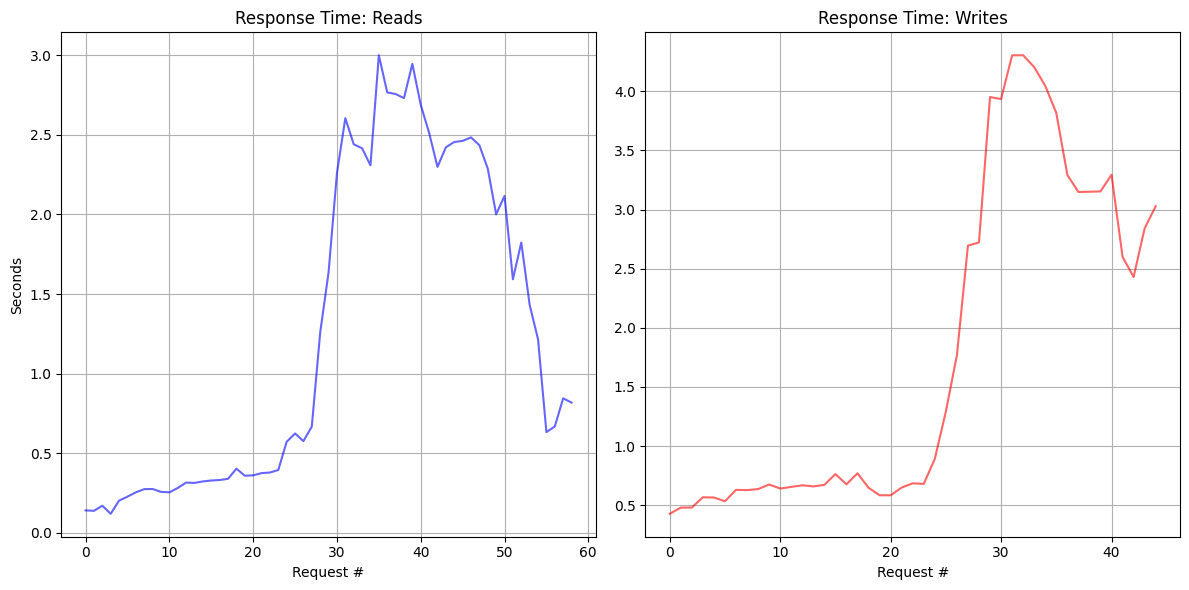

In [33]:
plot_results()

In [34]:
setup_test_data()

if TARGET_ISBN == "0000000000" or TARGET_ISBN is None:
    print("Test aborted.")
    exit()

print(f"\n[START] Launching {NUM_USERS} threads for {DURATION_SEC} seconds...")

threads = []
for i in range(NUM_USERS):
    t = threading.Thread(target=simulate_read_write, args=(i,))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("\n--- OPTIMIZED RESULTS ---")
print(f"Total Reads:  {stats['read_ops']} (Errors: {stats['read_errors']})")
print(f"Total Writes: {stats['write_ops']} (Errors: {stats['write_errors']})")
print(f"Deadlocks:    {stats['deadlocks']}")

if stats['read_time']:
    print(f"Avg Read Time:  {sum(stats['read_time'])/len(stats['read_time']):.4f}s")
if stats['write_time']:
    print(f"Avg Write Time: {sum(stats['write_time'])/len(stats['write_time']):.4f}s")

[INFO] Preparing data...
[INFO] Loaded 1000 ISBNs for random testing.
[INFO] Bulk initializing 1000 docs in MongoDB...
[OK] MongoDB and MySQL ready.

[START] Launching 50 threads for 5 seconds...

--- OPTIMIZED RESULTS ---
Total Reads:  244 (Errors: 0)
Total Writes: 233 (Errors: 9)
Deadlocks:    0
Avg Read Time:  0.6423s
Avg Write Time: 0.8440s


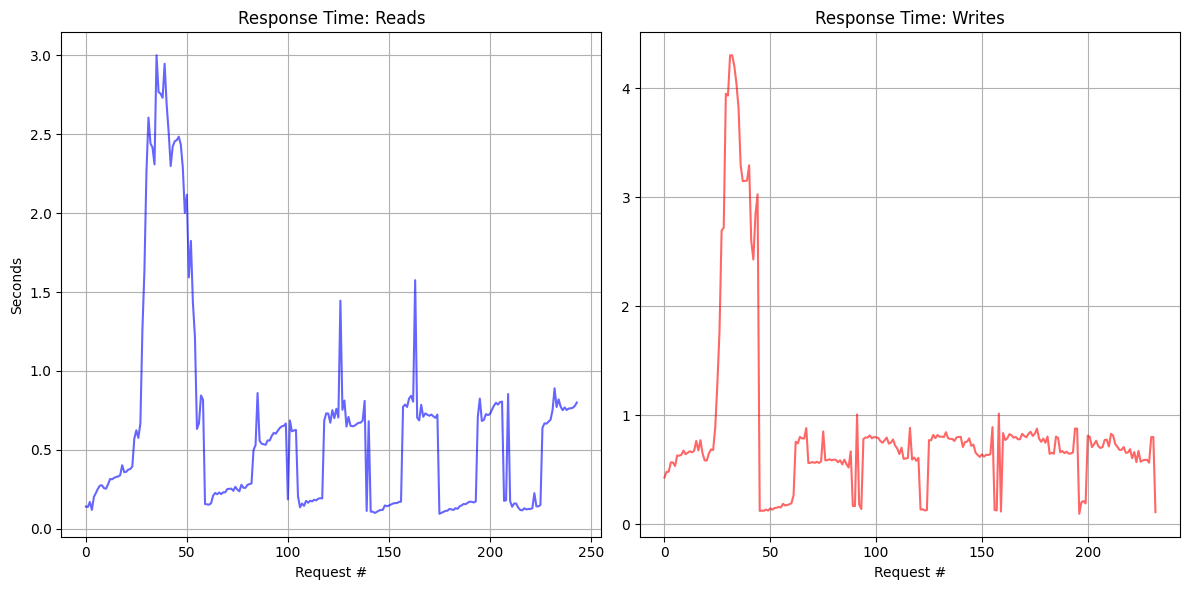

In [35]:
plot_results()

In [36]:
setup_test_data()

if TARGET_ISBN == "0000000000" or TARGET_ISBN is None:
    print("Test aborted.")
    exit()

print(f"\n[START] Launching {NUM_USERS} threads for {DURATION_SEC} seconds...")

threads = []
for i in range(NUM_USERS):
    t = threading.Thread(target=user_simulation, args=(i,))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("\n--- OPTIMIZED RESULTS ---")
print(f"Total Reads:  {stats['read_ops']} (Errors: {stats['read_errors']})")
print(f"Total Writes: {stats['write_ops']} (Errors: {stats['write_errors']})")
print(f"Deadlocks:    {stats['deadlocks']}")

if stats['read_time']:
    print(f"Avg Read Time:  {sum(stats['read_time'])/len(stats['read_time']):.4f}s")
if stats['write_time']:
    print(f"Avg Write Time: {sum(stats['write_time'])/len(stats['write_time']):.4f}s")

[INFO] Preparing data...
[INFO] Loaded 1000 ISBNs for random testing.
[INFO] Bulk initializing 1000 docs in MongoDB...
[OK] MongoDB and MySQL ready.

[START] Launching 50 threads for 5 seconds...
[CONFLICT] User 1004 wrote 4 but read 8
[RETRY 1/3] User 1031 stuck (A_TO_B)...
[RETRY 1/3] User 1034 stuck (A_TO_B)...
[RETRY 1/3] User 1035 stuck (A_TO_B)...
[RETRY 1/3] User 1039 stuck (B_TO_A)...
[RETRY 1/3] User 1047 stuck (B_TO_A)...
[RETRY 1/3] User 1011 stuck (A_TO_B)...
[CONFLICT] User 1025 wrote 8 but read 7
[CONFLICT] User 1026 wrote 7 but read 6
[RETRY 1/3] User 1023 stuck (A_TO_B)...
[CONFLICT] User 1040 wrote 1 but read 10
[RETRY 1/3] User 1029 stuck (A_TO_B)...
[RETRY 2/3] User 1034 stuck (A_TO_B)...
[RETRY 1/3] User 1022 stuck (A_TO_B)...
[RETRY 1/3] User 1002 stuck (B_TO_A)...
[RETRY 1/3] User 1016 stuck (B_TO_A)...
[CONFLICT] User 1019 wrote 4 but read 1
[RETRY 1/3] User 1043 stuck (B_TO_A)...
[RETRY 1/3] User 1006 stuck (A_TO_B)...
[RETRY 1/3] User 1045 stuck (B_TO_A)...
[CO

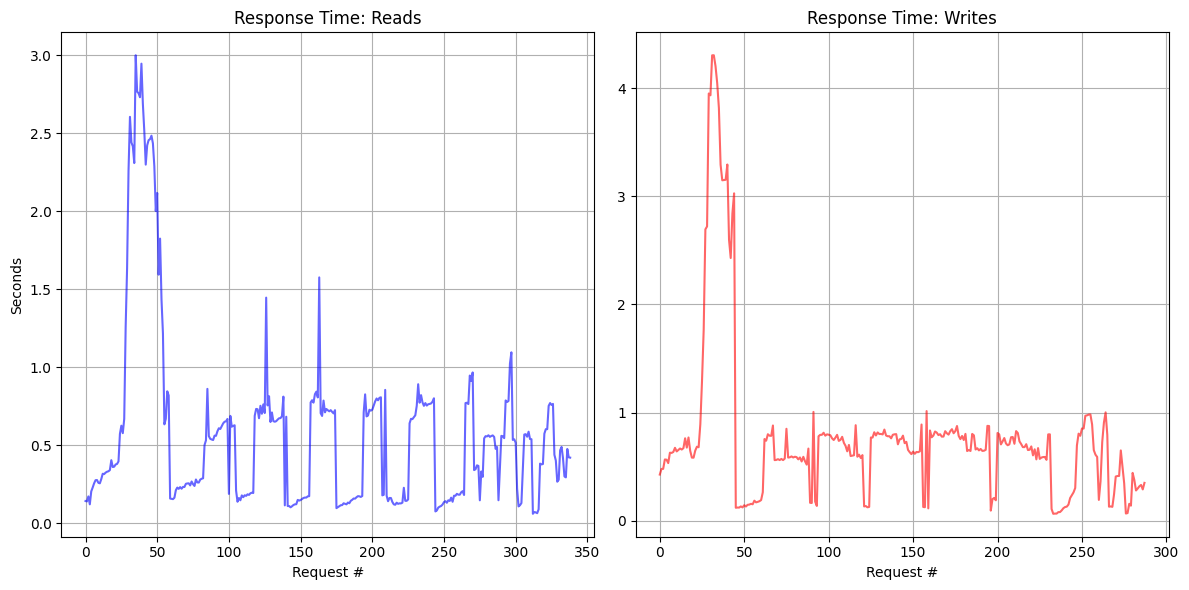

In [37]:
plot_results()